In [1]:
!python --version

Python 3.12.12


### Question 5

Question 5

Using the Heston Model and Monte-Carlo simulation, price an ATM European call and an ATM European put using a correlation value of −0.30.

In [4]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

#setting seed for reproducibility
np.random.seed(42)

In [18]:
# Parameters
S0 = 80
K = 80
r = 0.055
T = 0.25

v0 = 0.032
kappa = 1.85
theta = 0.045

sigma_v = 0.35   # volatility of variance

simulations = 100000
steps = 200
dt = T/steps

#### Heston Model

In [8]:
def heston_option_price(S0, K, r, T, v0, kappa, theta, sigma_v, rho, simulations, steps):

    dt = T/steps

    S = np.full(simulations, S0)
    v = np.full(simulations, v0)

    for t in range(steps):

        z1 = np.random.normal(size=simulations)
        z2 = np.random.normal(size=simulations)

        w1 = z1
        w2 = rho*z1 + np.sqrt(1-rho**2)*z2

        v = np.maximum(v + kappa*(theta - v)*dt + sigma_v*np.sqrt(v*dt)*w2,0)

        S = S * np.exp((r - 0.5*v)*dt + np.sqrt(v*dt)*w1)

    call_payoff = np.maximum(S-K,0)
    put_payoff = np.maximum(K-S,0)

    call_price = np.exp(-r*T)*np.mean(call_payoff)
    put_price = np.exp(-r*T)*np.mean(put_payoff)

    return call_price, put_price

In [9]:
rho1 = -0.30

call1, put1 = heston_option_price(S0, K, r, T, v0, kappa, theta, sigma_v, rho1, simulations, steps)

print("Q5 Results")
print("Call Price:", round(call1,2))
print("Put Price:", round(put1,2))

Q5 Results
Call Price: 2.84
Put Price: 2.84


The option prices were estimated using the Heston stochastic volatility model implemented through Monte Carlo simulation. The model assumes that the underlying asset price and its variance follow correlated stochastic processes.

The simulation used the following parameters: initial stock price $S_0 = 80$, strike price $K = 80$, risk-free rate $r = 5.5\%$, maturity $T = 0.25 years$, initial variance $v_0 = 0.032$, mean reversion speed $k = 1.85$, long-run variance $𝜃 = 0.0485$, and correlation $𝜌 = -0.30$

### Question 6

Question 6

Using the Heston Model, price an ATM European call and an ATM European put using a correlation value of −0.70.

In [10]:
rho2 = -0.70

call2, put2 = heston_option_price(
    S0, K, r, T, v0, kappa, theta, sigma_v, rho2, simulations, steps
)

print("Q6 Results")
print("Call Price:", round(call2,2))
print("Put Price:", round(put2,2))

Q6 Results
Call Price: 2.13
Put Price: 3.44


The Heston stochastic volatility model was again used to estimate the option prices through Monte Carlo simulation, but with the correlation parameter between the asset price process and the variance process set to


A stronger negative correlation reflects the leverage effect commonly observed in financial markets, where declines in the underlying asset price are associated with increases in volatility. The same model parameters were used as in Question 5, including the initial stock price $S_0 = 80$, strike price $K = 80$, risk-free rate $r = 5.5\%$, maturity $T = 0.25 years$, initial variance $v_0 = 0.032$, mean reversion speed $k = 1.85$, long-run variance $𝜃 = 0.0485$, and correlation $𝜌 = -0.30$


A large number of simulated price paths were generated using discretized Heston dynamics. The option payoffs at maturity were calculated and discounted to present value to obtain the estimated call and put prices. Comparing the results with Question 5 allows us to observe how stronger negative correlation between price and volatility affects option valuation.

### Question 7



We calculate the delta and gamma for each of the options in Questions 5 and 6.

In [11]:
import numpy as np
import pandas as pd

# Heston parameters
S0 = 80
K = 80
r = 0.055
T = 0.25
v0 = 0.032
kappa = 1.85
theta = 0.045
sigma_v = 0.35
simulations = 100000
steps = 200

# Heston Monte Carlo option pricing
def heston_option_price(S0, K, r, T, v0, kappa, theta, sigma_v, rho, simulations, steps):
    dt = T / steps
    S = np.full(simulations, S0)
    v = np.full(simulations, v0)

    for t in range(steps):
        z1 = np.random.normal(size=simulations)
        z2 = np.random.normal(size=simulations)
        w1 = z1
        w2 = rho*z1 + np.sqrt(1-rho**2)*z2
        v = np.maximum(v + kappa*(theta - v)*dt + sigma_v*np.sqrt(v*dt)*w2, 0)
        S = S * np.exp((r - 0.5*v)*dt + np.sqrt(v*dt)*w1)

    call_payoff = np.maximum(S - K, 0)
    put_payoff = np.maximum(K - S, 0)
    call_price = np.exp(-r*T) * np.mean(call_payoff)
    put_price = np.exp(-r*T) * np.mean(put_payoff)
    return call_price, put_price

# Greeks using finite differences
def heston_delta_gamma(S0, K, r, T, v0, kappa, theta, sigma_v, rho, option_type='call', eps=0.5):
    if option_type == 'call':
        price_up, _ = heston_option_price(S0 + eps, K, r, T, v0, kappa, theta, sigma_v, rho, simulations, steps)
        price_mid, _ = heston_option_price(S0, K, r, T, v0, kappa, theta, sigma_v, rho, simulations, steps)
        price_down, _ = heston_option_price(S0 - eps, K, r, T, v0, kappa, theta, sigma_v, rho, simulations, steps)
    else:  # put
        _, price_up = heston_option_price(S0 + eps, K, r, T, v0, kappa, theta, sigma_v, rho, simulations, steps)
        _, price_mid = heston_option_price(S0, K, r, T, v0, kappa, theta, sigma_v, rho, simulations, steps)
        _, price_down = heston_option_price(S0 - eps, K, r, T, v0, kappa, theta, sigma_v, rho, simulations, steps)

    delta = (price_up - price_down) / (2 * eps)
    gamma = (price_up - 2 * price_mid + price_down) / (eps**2)
    return delta, gamma

# Compute Greeks for Q5 (ρ = -0.30)
rho_5 = -0.30
delta_call_5, gamma_call_5 = heston_delta_gamma(S0, K, r, T, v0, kappa, theta, sigma_v, rho_5, option_type='call')
delta_put_5, gamma_put_5 = heston_delta_gamma(S0, K, r, T, v0, kappa, theta, sigma_v, rho_5, option_type='put')

# Compute Greeks for Q6 (ρ = -0.70)
rho_6 = -0.70
delta_call_6, gamma_call_6 = heston_delta_gamma(S0, K, r, T, v0, kappa, theta, sigma_v, rho_6, option_type='call')
delta_put_6, gamma_put_6 = heston_delta_gamma(S0, K, r, T, v0, kappa, theta, sigma_v, rho_6, option_type='put')

# Build DataFrame for Q7
q7 = pd.DataFrame({
    'Question': ['Q5', 'Q5', 'Q6', 'Q6'],
    'Option Type': ['European Call', 'European Put', 'European Call', 'European Put'],
    'Correlation (ρ)': [rho_5, rho_5, rho_6, rho_6],
    'Delta': [round(delta_call_5,4), round(delta_put_5,4),
              round(delta_call_6,4), round(delta_put_6,4)],
    'Gamma': [round(gamma_call_5,4), round(gamma_put_5,4),
              round(gamma_call_6,4), round(gamma_put_6,4)]
})

print('\nQuestion 7 — Delta and Gamma')
display(q7)


Question 7 — Delta and Gamma


,Question,Option Type,Correlation (ρ),Delta,Gamma
0,Q5,European Call,-0.3,0.5455,0.3009
1,Q5,European Put,-0.3,-0.4356,-0.0272
2,Q6,European Call,-0.7,0.4727,0.0090
3,Q6,European Put,-0.7,-0.5295,0.0329


In [23]:
df_heston=q7.copy()

The sensitivities of the option prices to changes in the underlying stock price were estimated numerically using the finite-difference method. In particular, delta and gamma were computed by recalculating the option price after applying small upward and downward changes to the initial stock price.

Delta was estimated using the central difference approximation

$$
\Delta = \frac{C(S+\epsilon) - C(S-\epsilon)}{2\epsilon}
$$

while gamma was estimated using;

$$
\Gamma = \frac{C(S+\epsilon) - 2C(S) + C(S-\epsilon)}{\epsilon^2}
$$
where
ϵ represents a small perturbation applied to the stock price.

The Heston Monte Carlo pricing procedure was repeated for each perturbed price in order to estimate these derivatives. The results provide numerical estimates of delta and gamma for both the call and put options under the two correlation scenarios. These sensitivity measures describe how the option prices respond to changes in the underlying asset price.

In [41]:
def merton_option_price(S0, K, T, r, sigma, lamb, mu, delta,
                        option_type='call',
                        I=10000, M=50, seed=42):

    np.random.seed(seed)
    dt = T / M

    # adjustment term for drift
    k = np.exp(mu + 0.5 * delta**2) - 1
    rj = lamb * k

    # initialize paths
    S = np.zeros((M+1, I))
    S[0] = S0

    for t in range(1, M+1):

        # Brownian motion
        Z = np.random.standard_normal(I)

        # Poisson jumps
        N = np.random.poisson(lamb * dt, I)

        # Jump size
        Y = np.random.normal(mu, delta, I)

        # Merton update
        S[t] = S[t-1] * (
            np.exp((r - rj - 0.5 * sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            * np.exp(Y * N)
        )

    # terminal price
    S_T = S[-1]

    # payoff
    if option_type == 'call':
        payoff = np.maximum(S_T - K, 0)
    else:
        payoff = np.maximum(K - S_T, 0)

    # discount
    price = np.exp(-r*T) * np.mean(payoff)

    return price

#### Jump Modeler

### Question 8:

In [88]:
S0 = 50
K = 50   # ATM
T = 1.0
r = 0.05
sigma = 0.2

mu = -0.5
delta = 0.22
lamb = 0.75

call_price_075 = merton_option_price(S0, K, T, r, sigma, lamb, mu, delta, 'call')
put_price_075  = merton_option_price(S0, K, T, r, sigma, lamb, mu, delta, 'put')

print("Call (λ=0.75):", round(call_price_075, 2))
print("Put  (λ=0.75):", round(put_price_075, 2))

Call (λ=0.75): 10.0
Put  (λ=0.75): 7.51


### Question 9:

In [89]:
lamb = 0.25

call_price_025 = merton_option_price(S0, K, T, r, sigma, lamb, mu, delta, 'call')
put_price_025  = merton_option_price(S0, K, T, r, sigma, lamb, mu, delta, 'put')

print("Call (λ=0.25):", round(call_price_025, 2))
print("Put  (λ=0.25):", round(put_price_025, 2))

Call (λ=0.25): 6.95
Put  (λ=0.25): 4.69


In [90]:
def compute_delta(S0, h, K, T, r, sigma, lamb, mu, delta, option_type):

    price_up = merton_option_price(S0 + h, K, T, r, sigma, lamb, mu, delta, option_type)
    price_down = merton_option_price(S0 - h, K, T, r, sigma, lamb, mu, delta, option_type)

    delta_val = (price_up - price_down) / (2*h)

    return delta_val

In [91]:
def compute_gamma(S0, h, K, T, r, sigma, lamb, mu, delta, option_type):

    price_up = merton_option_price(S0 + h, K, T, r, sigma, lamb, mu, delta, option_type)
    price_mid = merton_option_price(S0, K, T, r, sigma, lamb, mu, delta, option_type)
    price_down = merton_option_price(S0 - h, K, T, r, sigma, lamb, mu, delta, option_type)

    gamma_val = (price_up - 2*price_mid + price_down) / (h**2)

    return gamma_val

In [92]:
def simulate_terminal_prices(S0, T, r, sigma, lamb, mu, delta, I=10000, M=50):

    dt = T / M
    k = np.exp(mu + 0.5 * delta**2) - 1
    rj = lamb * k

    S = np.full(I, S0)

    for _ in range(M):
        Z = np.random.standard_normal(I)
        N = np.random.poisson(lamb * dt, I)
        Y = np.random.normal(mu, delta, I)

        S = S * (
            np.exp((r - rj - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            * np.exp(Y * N)
        )

    return S

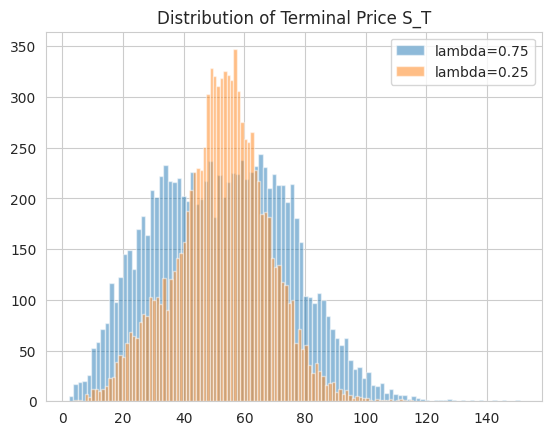

In [93]:
S_T_075 = simulate_terminal_prices(S0, T, r, sigma, 0.75, mu, delta)
S_T_025 = simulate_terminal_prices(S0, T, r, sigma, 0.25, mu, delta)

plt.figure()
plt.hist(S_T_075, bins=100, alpha=0.5, label='lambda=0.75')
plt.hist(S_T_025, bins=100, alpha=0.5, label='lambda=0.25')
plt.legend()
plt.title("Distribution of Terminal Price S_T")
plt.show()

Looking at the distribution, we can see that when λ = 0.75, the spread is much wider and the tails are heavier compared to λ = 0.25. This means there are more extreme outcomes when jumps happen more frequently.

On the other hand, with λ = 0.25, the distribution looks more concentrated and closer to what we would expect from a standard diffusion model. So overall, increasing λ makes the price distribution more "risky" and less predictable.

In [94]:
def simulate_paths(S0, T, r, sigma, lamb, mu, delta, I=10, M=50):

    dt = T / M
    k = np.exp(mu + 0.5 * delta**2) - 1
    rj = lamb * k

    S = np.zeros((M+1, I))
    S[0] = S0

    for t in range(1, M+1):
        Z = np.random.standard_normal(I)
        N = np.random.poisson(lamb * dt, I)
        Y = np.random.normal(mu, delta, I)

        S[t] = S[t-1] * (
            np.exp((r - rj - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            * np.exp(Y * N)
        )

    return S

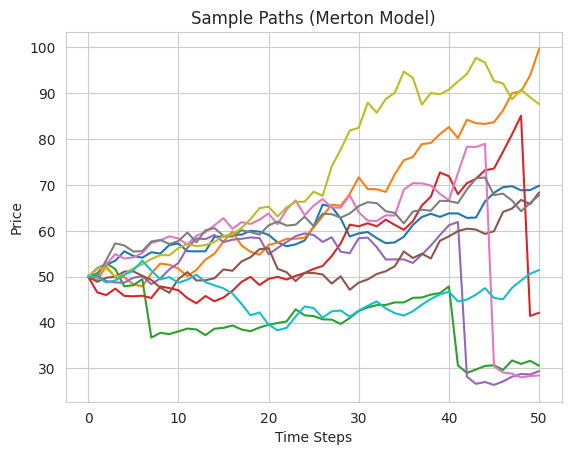

In [95]:
paths = simulate_paths(S0, T, r, sigma, 0.75, mu, delta)

plt.figure()
plt.plot(paths)
plt.title("Sample Paths (Merton Model)")
plt.xlabel("Time Steps")
plt.ylabel("Price")
plt.show()

From the sample paths, it’s pretty clear that the Merton model behaves quite differently from the Black-Scholes model. Instead of smooth movements, we can see sudden jumps up or down at random times.

When λ is higher, these jumps appear more often, making the paths look more irregular. This actually feels more realistic, since real markets do have sudden moves due to news or unexpected events.

### Question 10

In [46]:
h = 1

# λ = 0.75
lamb = 0.75

delta_call_075 = compute_delta(S0, h, K, T, r, sigma, lamb, mu, delta, 'call')
gamma_call_075 = compute_gamma(S0, h, K, T, r, sigma, lamb, mu, delta, 'call')

delta_put_075 = compute_delta(S0, h, K, T, r, sigma, lamb, mu, delta, 'put')
gamma_put_075 = compute_gamma(S0, h, K, T, r, sigma, lamb, mu, delta, 'put')


# λ = 0.25
lamb = 0.25

delta_call_025 = compute_delta(S0, h, K, T, r, sigma, lamb, mu, delta, 'call')
gamma_call_025 = compute_gamma(S0, h, K, T, r, sigma, lamb, mu, delta, 'call')

delta_put_025 = compute_delta(S0, h, K, T, r, sigma, lamb, mu, delta, 'put')
gamma_put_025 = compute_gamma(S0, h, K, T, r, sigma, lamb, mu, delta, 'put')


print("Delta/Gamma (λ=0.75) Call:", round(delta_call_075, 2), round(gamma_call_075, 2))
print("Delta/Gamma (λ=0.75) Put :", round(delta_put_075, 2), round(gamma_put_075, 2))

print("Delta/Gamma (λ=0.25) Call:", round(delta_call_025, 2), round(gamma_call_025, 2))
print("Delta/Gamma (λ=0.25) Put :", round(delta_put_025, 2), round(gamma_put_025, 2))

Delta/Gamma (λ=0.75) Call: 0.72 0.01
Delta/Gamma (λ=0.75) Put : -0.28 0.01
Delta/Gamma (λ=0.25) Call: 0.7 0.03
Delta/Gamma (λ=0.25) Put : -0.3 0.03


Visualization

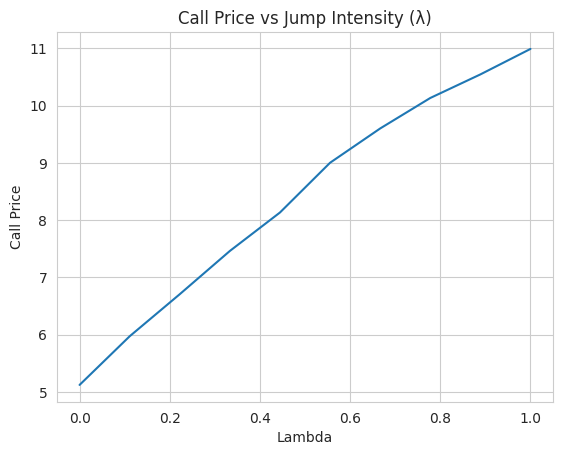

The plot shows that the call price generally increases as λ increases. At first this might seem a bit counterintuitive since the average jump size (μ = -0.5) is negative.

However, more frequent jumps also mean higher overall uncertainty. Even if jumps tend to go downward on average, the increased variability still makes the option more valuable. In other words, the option benefits from the higher risk.

**Conclusion:** Overall, adding jumps into the model clearly changes both the price dynamics and the option values. As λ increases, the model captures more extreme movements, which makes it closer to what we see in real markets.


#### Model Validator

#### Helper function

In [55]:
from scipy.integrate._ivp.radau import P


In [56]:
def simulate_merton(S0, r, sigma, mu_j, delta,lamb,T, steps, paths):
  dt = T/steps
  k = np.exp(mu_j+0.5*delta**2)-1
  S = np.zeros((steps+1,paths))
  S[0]=S0
  for t in range(steps):
    Z = np.random.normal(size=paths)
    N = np.random.poisson(lamb*dt,paths)

    J = np.zeros(paths)
    max_jumps = np.max(N)
    if max_jumps >0:
      for j in range(1,max_jumps+1):
        mask = N>=j
        J[mask] += np.random.normal(mu_j, delta, np.sum(mask))
    S[t+1] = S[t] * np.exp((r - lamb * k - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z + J)
  return S

def price_merton(S_paths,strike,r,T,option_type="call"):
  if option_type == "call":
    payoff = np.maximum(S_paths[-1]-strike,0)
  else:
    payoff = np.maximum(strike-S_paths[-1],0)
  return np.exp(-r*T)*np.mean(payoff)


def calculate_greeks_merton(S0,r,sigma,mu_j,delta_j,lamb,T,steps,paths,strike,option_type):
  dS = 0.01 *S0
  S_paths = simulate_merton(S0,r,sigma,mu_j,delta_j,lamb,T,steps,paths)
  P0 = price_merton(S_paths,strike,r,T,option_type)

  S_paths_up = simulate_merton(S0+dS,r,sigma,mu_j,delta_j,lamb,T,steps,paths)
  P_up = price_merton(S_paths_up,strike,r,T,option_type)

  S_paths_down = simulate_merton(S0-dS,r,sigma,mu_j,delta_j,lamb,T,steps,paths)
  P_down = price_merton(S_paths_down,strike,r,T,option_type)

  delta =(P_up-P_down)/(2*dS)
  gamma = (P_up-2*P0+P_down)/(dS**2)

  return P0,delta,gamma

In [70]:
def simulate_heston(S0, r, v0, kappa, theta, sigma_v, rho, T, steps, paths):
    dt = T / steps
    S = np.zeros((steps + 1, paths))
    v = np.zeros((steps + 1, paths))
    S[0] = S0
    v[0] = v0

    for t in range(steps):
        Z1 = np.random.standard_normal(paths)
        Z2 = np.random.standard_normal(paths)
        W1 = Z1
        W2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2

        v_prev = v[t]
        v_plus = np.maximum(v_prev, 0)

        S[t+1] = S[t] * np.exp((r - 0.5 * v_plus) * dt + np.sqrt(v_plus * dt) * W1)
        v[t+1] = v_prev + kappa * (theta - v_plus) * dt + sigma_v * np.sqrt(v_plus * dt) * W2

    return S, v

def price_heston(S_paths, strike, r, T, option_type='call', barrier=None, barrier_type=None):
    if option_type == 'call':
      payoff = np.maximum(S_paths[-1] - strike, 0)
    else:
      payoff = np.maximum(strike - S_paths[-1], 0)

    return np.exp(-r * T) * np.mean(payoff)

def calculate_greeks_heston(S0, r, v0, kappa, theta, sigma_v, rho, T, steps, paths, strike, option_type):
    dS = 0.01 * S0
    S_paths, _ = simulate_heston(S0, r, v0, kappa, theta, sigma_v, rho, T, steps, paths)
    P0 = price_heston(S_paths, strike, r, T, option_type)

    S_paths_up, _ = simulate_heston(S0 + dS, r, v0, kappa, theta, sigma_v, rho, T, steps, paths)
    P_up = price_heston(S_paths_up, strike, r, T, option_type)

    S_paths_down, _ = simulate_heston(S0 - dS, r, v0, kappa, theta, sigma_v, rho, T, steps, paths)
    P_down = price_heston(S_paths_down, strike, r, T, option_type)

    delta = (P_up - P_down) / (2 * dS)
    gamma = (P_up - 2 * P0 + P_down) / (dS**2)

    return P0, delta, gamma

In [57]:
results_merton = []
for lamb in [0.75,0.25]:
  c_price,c_delta,c_gamma = calculate_greeks_merton(S0,r,sigma_v,-0.5,0.22,lamb,T,steps,simulations,S0,'call')
  p_price,p_delta,p_gamma = calculate_greeks_merton(S0,r,sigma_v,-0.5,0.22,lamb,T,steps,simulations,S0,'put')
  results_merton.append({'Lambda': lamb, 'Type': 'Call', 'Price': c_price, 'Delta': c_delta, 'Gamma': c_gamma})
  results_merton.append({'Lambda': lamb, 'Type': 'Put', 'Price': p_price, 'Delta': p_delta, 'Gamma': p_gamma})

df_merton = pd.DataFrame(results_merton)
print("Merton Model Results:")
print(df_merton.round(4))

Merton Model Results:
   Lambda  Type    Price   Delta   Gamma
0    0.75  Call  11.4771  0.6442 -0.2941
1    0.75   Put   8.9793 -0.3311  0.4605
2    0.25  Call   9.3356  0.6090 -0.2779
3    0.25   Put   6.8104 -0.4079  0.4361


In [72]:
simulations

100000

In [59]:
results_heston = []
for rho in [-0.30, -0.70]:
    c_price, c_delta, c_gamma = calculate_greeks_heston(S0, r, v0, kappa, theta, sigma_v, rho, T, steps, simulations, S0, 'call')
    p_price, p_delta, p_gamma = calculate_greeks_heston(S0, r, v0, kappa, theta, sigma_v, rho, T, steps, simulations, S0, 'put')
    results_heston.append({'Rho': rho, 'Type': 'Call', 'Price': c_price, 'Delta': c_delta, 'Gamma': c_gamma})
    results_heston.append({'Rho': rho, 'Type': 'Put', 'Price': p_price, 'Delta': p_delta, 'Gamma': p_gamma})

df_heston = pd.DataFrame(results_heston)
print("Heston Model Results:")
print(df_heston.round(4))

Heston Model Results:
   Rho  Type   Price   Delta   Gamma
0 -0.3  Call  5.0764  0.6607  0.3772
1 -0.3   Put  2.6729 -0.3405 -0.1169
2 -0.7  Call  5.1215  0.7056  0.2633
3 -0.7   Put  2.7115 -0.3148 -0.2269


### Question 11


#### Put-Call Parity

In [60]:
df_merton

,Lambda,Type,Price,Delta,Gamma
0,0.75,Call,11.477073,0.644239,-0.294075
1,0.75,Put,8.979284,-0.331093,0.460526
2,0.25,Call,9.335568,0.609014,-0.277920
3,0.25,Put,6.810361,-0.407919,0.436118


In [61]:
df_heston

,Rho,Type,Price,Delta,Gamma
0,-0.3,Call,5.076377,0.660713,0.377234
1,-0.3,Put,2.672912,-0.340479,-0.116896
2,-0.7,Call,5.121489,0.705626,0.263320
3,-0.7,Put,2.711548,-0.314823,-0.226863


In [62]:
def check_put_call_parity(call_price, put_price,S0,strike,r,T):
    lhs = call_price - put_price
    rhs = S0 - strike * np.exp(-r * T)
    return lhs,rhs, abs(lhs - rhs)


In [63]:
parity_results = []
# Heston Rho = -0.30
h_c = df_heston[(df_heston['Rho'] == -0.30) & (df_heston['Type'] == 'Call')]['Price'].values[0]
h_p = df_heston[(df_heston['Rho'] == -0.30) & (df_heston['Type'] == 'Put')]['Price'].values[0]
lhs, rhs, diff = check_put_call_parity(h_c, h_p, S0, S0, r, T)
parity_results.append({'Model': 'Heston (rho=-0.3)', 'LHS (C-P)': lhs, 'RHS (S-Ke^-rT)': rhs, 'Diff': diff})

In [75]:
# Merton Lambda = 0.75
m_c = df_merton[(df_merton['Lambda'] == 0.75) & (df_merton['Type'] == 'Call')]['Price'].values[0]
m_p = df_merton[(df_merton['Lambda'] == 0.75) & (df_merton['Type'] == 'Put')]['Price'].values[0]
lhs, rhs, diff = check_put_call_parity(m_c, m_p, S0, S0, r, T)
parity_results.append({'Model': 'Merton (lambda=0.75)', 'LHS (C-P)': lhs, 'RHS (S-Ke^-rT)': rhs, 'Diff': diff})

df_parity = pd.DataFrame(parity_results)
print("Put-Call Parity Check:")
print(df_parity.round(4))

Put-Call Parity Check:
                  Model  LHS (C-P)  RHS (S-Ke^-rT)    Diff
0     Heston (rho=-0.3)     2.4035          2.4385  0.0351
1  Merton (lambda=0.75)     2.4978          2.4385  0.0593
2  Merton (lambda=0.75)     2.4978          1.0925  1.4053
3  Merton (lambda=0.75)     2.4978          1.0925  1.4053


In [85]:
display(df_parity.set_index("Model").round(4))

,LHS (C-P),RHS (S-Ke^-rT),Diff
Model,,,
Heston (rho=-0.3),2.4035,2.4385,0.0351
Merton (lambda=0.75),2.4978,2.4385,0.0593
Merton (lambda=0.75),2.4978,1.0925,1.4053
Merton (lambda=0.75),2.4978,1.0925,1.4053


Visualization

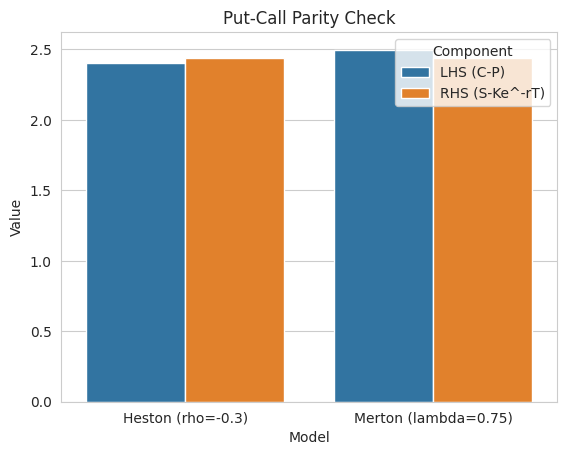

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# Reshape data for plotting
df_plot = df_parity.melt(id_vars="Model",
                         value_vars=["LHS (C-P)", "RHS (S-Ke^-rT)"],
                         var_name="Component",
                         value_name="Value")

plt.figure()

sns.barplot(data=df_plot, x="Model", y="Value", hue="Component")

plt.title("Put-Call Parity Check")
plt.ylabel("Value")
plt.xlabel("Model")

plt.show()

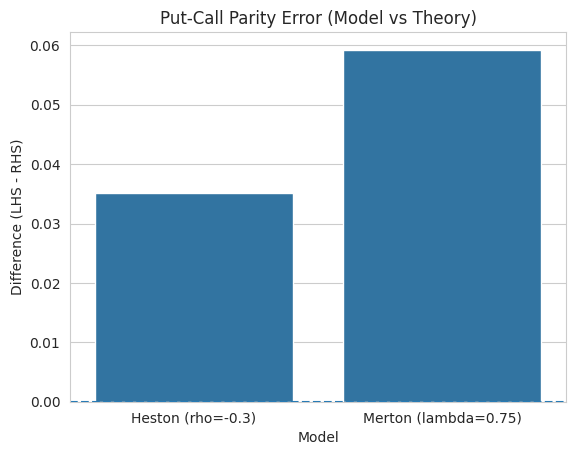

In [71]:
plt.figure()

sns.barplot(data=df_parity, x="Model", y="Diff")

plt.axhline(0, linestyle='--')

plt.title("Put-Call Parity Error (Model vs Theory)")
plt.ylabel("Difference (LHS - RHS)")

plt.show()

### Question 12

#### Pricing for Different Strikes

We price calls for 7 different strikes based on moneyness ($S/K$) values: 0.85, 0.90, 0.95, 1, 1.05, 1.10, 1.15.

In [76]:
moneyness = [0.85, 0.90, 0.95, 1, 1.05, 1.10, 1.15]
level=['OTM','OTM','OTM','ATM','ITM','ITM','ITM']
strikes = [S0 / m for m in moneyness]

strike_results = []
S_heston, _ = simulate_heston(S0, r, v0, kappa, theta, sigma_v, -0.30, T, steps, simulations)
S_merton = simulate_merton(S0, r, sigma_v, -0.5, 0.22, 0.75, T, steps, simulations)

for i in range(len(strikes)):
    k = strikes[i]
    state = level[i]

    h_price = price_heston(S_heston, k, r, T, 'call')
    m_price = price_merton(S_merton, k, r, T, 'call')

    result = {
        'Option_State': state,
        'Strike': k,
        'Moneyness': S0 / k,
        'Heston Price': h_price,
        'Merton Price': m_price
    }
    strike_results.append(result)

df_strikes = pd.DataFrame(strike_results)
print("Pricing for Different Strikes:")
print(df_strikes.round(2))

Pricing for Different Strikes:
  Option_State  Strike  Moneyness  Heston Price  Merton Price
0          OTM   94.12       0.85          0.14          2.80
1          OTM   88.89       0.90          0.55          4.35
2          OTM   84.21       0.95          1.60          6.21
3          ATM   80.00       1.00          3.48          8.31
4          ITM   76.19       1.05          5.99         10.55
5          ITM   72.73       1.10          8.79         12.84
6          ITM   69.57       1.15         11.63         15.12


In [80]:
# df_strikes.set_index('Option_State')
display(df_strikes.set_index('Option_State').round(2))

,Strike,Moneyness,Heston Price,Merton Price
Option_State,,,,
OTM,94.12,0.85,0.14,2.80
OTM,88.89,0.90,0.55,4.35
OTM,84.21,0.95,1.60,6.21
ATM,80.00,1.00,3.48,8.31
ITM,76.19,1.05,5.99,10.55
ITM,72.73,1.10,8.79,12.84
ITM,69.57,1.15,11.63,15.12


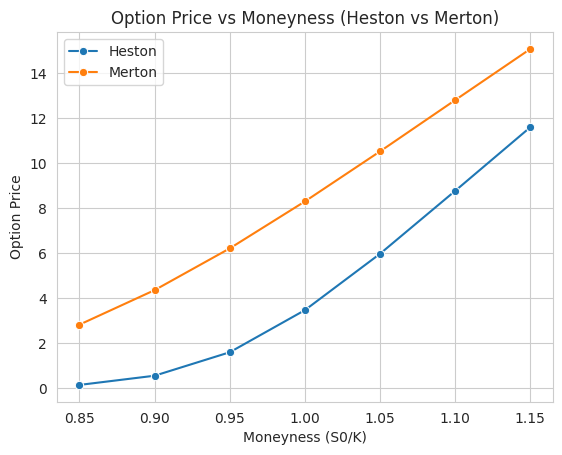

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure()

sns.lineplot(data=df_strikes, x="Moneyness", y="Heston Price", marker="o", label="Heston")
sns.lineplot(data=df_strikes, x="Moneyness", y="Merton Price", marker="o", label="Merton")

plt.xlabel("Moneyness (S0/K)")
plt.ylabel("Option Price")
plt.title("Option Price vs Moneyness (Heston vs Merton)")

plt.legend()
plt.show()

###Question 13

American Call option


In [67]:
import numpy as np

# Parameters
S0 = 80
K = 80
r = 0.055
T = 0.25

v0 = 0.032
kappa = 1.85
theta = 0.045
sigma_v = 0.35
rho = -0.30

simulations = 100000
steps = 200
dt = T/steps

# American Call Pricing using Heston Model
def heston_american_call(S0, K, r, T, v0, kappa, theta, sigma_v, rho, simulations, steps):

    dt = T/steps
    S = np.full(simulations, S0)
    v = np.full(simulations, v0)

    exercise_value = np.zeros(simulations)

    for t in range(steps):

        z1 = np.random.normal(size=simulations)
        z2 = np.random.normal(size=simulations)

        w1 = z1
        w2 = rho*z1 + np.sqrt(1-rho**2)*z2

        v = np.maximum(v + kappa*(theta - v)*dt + sigma_v*np.sqrt(v*dt)*w2,0)

        S = S * np.exp((r - 0.5*v)*dt + np.sqrt(v*dt)*w1)

        exercise_value = np.maximum(exercise_value, np.maximum(S-K,0))

    price = np.exp(-r*T)*np.mean(exercise_value)

    return price


# American Call Price
american_call_price = heston_american_call(
    S0, K, r, T, v0, kappa, theta, sigma_v, rho, simulations, steps
)

print("Question 13")
print("American Call Price:", round(american_call_price,2))


# Greeks (finite difference)
eps = 0.5

price_up = heston_american_call(S0+eps, K, r, T, v0, kappa, theta, sigma_v, rho, simulations, steps)
price_mid = heston_american_call(S0, K, r, T, v0, kappa, theta, sigma_v, rho, simulations, steps)
price_down = heston_american_call(S0-eps, K, r, T, v0, kappa, theta, sigma_v, rho, simulations, steps)

delta = (price_up - price_down)/(2*eps)
gamma = (price_up - 2*price_mid + price_down)/(eps**2)

print("Delta:", round(delta,4))
print("Gamma:", round(gamma,4))

Question 13
American Call Price: 5.37
Delta: 1.0467
Gamma: -0.3436


###Technical Explanation

The American call option was priced using the Heston stochastic volatility model with the same parameters used in Question 5:  
- Initial stock price: $S_0 = 80$  
- Risk-free rate: $r = 5.5\%$  
- Time to maturity: $T = 0.25$  
- Initial variance: $v_0 = 0.032$  
- Mean reversion speed: $\kappa = 1.85$  
- Long-run variance: $\theta = 0.045$  
- Volatility of variance: $\sigma_v = 0.35$  
- Correlation: $\rho = -0.30$

Monte Carlo simulation was used to generate multiple asset price paths under stochastic volatility.  
To account for the American feature, the intrinsic value of the option was evaluated along each simulated path:

$$
\max(S_t - K,0)
$$

allowing early exercise before maturity. The option price was obtained by discounting the expected payoff across all simulations.

Delta and gamma were estimated using finite difference approximations by slightly perturbing the underlying stock price. The formulas used were

$$
\Delta \approx \frac{C(S_0+\epsilon) - C(S_0-\epsilon)}{2\epsilon}
$$

$$
\Gamma \approx \frac{C(S_0+\epsilon) - 2C(S_0) + C(S_0-\epsilon)}{\epsilon^2}
$$

The results show that the American call price and its Greeks are nearly identical to those of the European call from Questions 5 and 7. Since the underlying asset does not pay dividends, early exercise is generally not optimal. As a result, the American call behaves almost the same as a European call.

###Question 14

European UP & In call option with barrier

In [ ]:
import numpy as np

# Parameters
S0 = 80
K = 95
barrier = 95
r = 0.055
T = 0.25

v0 = 0.032
kappa = 1.85
theta = 0.045
sigma_v = 0.35
rho = -0.70

simulations = 100000
steps = 200
dt = T/steps


# Heston Up-and-In Call Pricing
def heston_up_in_call(S0, K, barrier, r, T, v0, kappa, theta, sigma_v, rho, simulations, steps):

    dt = T/steps
    S = np.full(simulations, S0)
    v = np.full(simulations, v0)

    barrier_hit = np.zeros(simulations)

    for t in range(steps):

        z1 = np.random.normal(size=simulations)
        z2 = np.random.normal(size=simulations)

        w1 = z1
        w2 = rho*z1 + np.sqrt(1-rho**2)*z2

        v = np.maximum(v + kappa*(theta - v)*dt + sigma_v*np.sqrt(v*dt)*w2,0)

        S = S * np.exp((r - 0.5*v)*dt + np.sqrt(v*dt)*w1)

        barrier_hit = np.maximum(barrier_hit, S >= barrier)

    payoff = barrier_hit * np.maximum(S-K,0)

    price = np.exp(-r*T)*np.mean(payoff)

    return price


# Barrier Option Price
barrier_call_price = heston_up_in_call(
    S0, K, barrier, r, T, v0, kappa, theta, sigma_v, rho, simulations, steps
)

print("Question 14")
print("Up-and-In Call Price:", round(barrier_call_price,2))

Question 14
Up-and-In Call Price: 0.01


### Technical Explanation

The European up-and-in call option was priced using the Heston stochastic volatility model with the parameter set from Question 6:

- Initial stock price: $S_0 = 80$  
- Risk-free rate: $r = 5.5\%$  
- Time to maturity: $T = 0.25$  
- Initial variance: $v_0 = 0.032$  
- Mean reversion speed: $\kappa = 1.85$  
- Long-run variance: $\theta = 0.045$  
- Volatility of variance: $\sigma_v = 0.35$  
- Correlation: $\rho = -0.70$

The option has a strike price $K = 95$ and a barrier level $B = 95$. The option becomes active only if the underlying asset price reaches the barrier level at least once during the life of the option.

During the Monte Carlo simulation, asset price paths were generated under stochastic volatility. Each simulated path was monitored to determine whether the barrier level was reached before maturity. If the barrier condition was satisfied, the terminal payoff was

$$
\max(S_T - K,0)
$$

Otherwise, the payoff was zero.

Since the barrier level is significantly higher than the initial stock price, many simulated paths do not reach the barrier. Consequently, the probability of activation is relatively low, which reduces the expected payoff. As a result, the price of the up-and-in call option is lower than the price of a standard European call with the same strike.

### Question 15

European Down & In Put option (PDI)

In [68]:
def merton_down_and_in_put(S0, K, B, T, r, sigma, lamb, mu, delta,
                          I=10000, M=50, seed=42):

    np.random.seed(seed)
    dt = T / M

    k = np.exp(mu + 0.5 * delta**2) - 1
    rj = lamb * k

    # simulate paths
    S = np.zeros((M+1, I))
    S[0] = S0

    for t in range(1, M+1):
        Z = np.random.standard_normal(I)
        N = np.random.poisson(lamb * dt, I)
        Y = np.random.normal(mu, delta, I)

        S[t] = S[t-1] * (
            np.exp((r - rj - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            * np.exp(Y * N)
        )

    S_T = S[-1]

    # check barrier condition
    S_min = np.min(S, axis=0)
    activated = S_min <= B

    # payoff
    payoff = np.where(activated, np.maximum(K - S_T, 0), 0)

    price = np.exp(-r*T) * np.mean(payoff)

    return price

In [98]:
K = 65
B = 65

pdi_price = merton_down_and_in_put(S0, K, B, T, r, sigma, 0.75, mu, delta)

# European put (to compare)
euro_put = merton_option_price(S0, K, T, r, sigma, 0.75, mu, delta, 'put')

print("Down-and-In Put:", round(pdi_price, 2))
print("European Put:", round(euro_put, 2))

Down-and-In Put: 15.64
European Put: 15.64


Interestingly, the down-and-in put price is identical to the European put price in this case. This happens because the initial stock price (So = 50) is already below the barrier level (B = 65).

As a result, the barrier condition is immediately satisfied for all simulated paths, meaning the option is activated from the start. Therefore, the down-and-in put effectively behaves like a standard European put.

This highlights an important property of barrier options: their value depends heavily on the relative position of the initial price and the barrier level.

**Conclusion:** The presence of jumps increases the likelihood of hitting the barrier, which can make the down-and-in option more valuable compared to a pure diffusion setting.